# Hospital Readmission Prediction (10-Year Diabetes Dataset)
**Predicting 30-day readmission for diabetic patients from 10 years of US hospital records**

Mohammad Bhatti, BSc (Hons)

## Abstract
Roughly **1 in 9** discharges of a diabetic patient in this dataset was followed by a readmission within 30 days. Readmissions are expensive for hospitals and hard on patients, so the question this project asks is: **can we tell, at the moment of discharge, which patients are most at risk of coming back?**

Using ~99,000 hospital encounters of ~70,000 patients from 130 US hospitals between 1999 and 2008, I clean and prepare the data, explore what actually separates readmitted patients from everyone else, and then compare four classifiers inside a leakage-proof pipeline — with the train/test split dealt out **by patient**, so the model is never graded on a person it trained on. A tuned gradient-boosting model reaches a **test AUC of about 0.67** — readmission is a genuinely hard prediction problem, and published results on this dataset land in the same range. Used as a screening tool with a lowered decision threshold, the model catches **about 3 in 5 readmissions** while flagging about 38% of discharges for follow-up.

Two very different models — a logistic regression read through odds ratios and the gradient-boosting model read through feature importances — agree on what drives the risk: **the patient's hospitalization history — recent visits, prior stays on record, and whether the last stay already ended in a readmission — followed by where they were discharged to, their age, and their primary diagnosis**. Agreement between two unrelated models is good evidence the signal is real.


## Contents

**1. [Setup](#s1)**

**2. [Data & cleaning](#s2)** — placeholders, the repeat-patient leakage trap, encounters that can't be readmitted, the target

**3. [Exploring the data](#s3)** — imbalance, age, prior hospitalizations, discharge destination, numeric correlations

**4. [Feature preparation](#s4)** — grouping coded ID fields, diagnosis chapters, medications, patient history, what I dropped, the pipeline

**5. [Modeling](#s5)** — metric priority, baselines, tuning, test-set evaluation, a screening threshold

**6. [What drives readmission risk](#s6)** — odds ratios vs feature importances

**7. [Conclusion & limitations](#s7)**

**[Appendix](#appendix)** — feature reference


<a id="s1"></a>
# 1. Setup
Imports, one seed used everywhere, and a small chart style so every figure in the notebook reads the same way.

In [1]:
import numpy as np                                     # numerical arrays and math
import pandas as pd                                    # dataframes for tabular data
import matplotlib.pyplot as plt                        # plotting
from matplotlib.colors import LinearSegmentedColormap  # custom color ramps for the heatmaps

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score, GridSearchCV  # patient-grouped split + tuning
from sklearn.pipeline import Pipeline                  # chains preprocessing + model into one object
from sklearn.compose import ColumnTransformer          # different preprocessing per column group
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # category dummies; numeric features to one ruler
from sklearn.dummy import DummyClassifier              # the "no skill" floor to measure everything against
from sklearn.linear_model import LogisticRegression    # interpretable baseline (gives odds ratios)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # tree-ensemble models
from sklearn.utils.class_weight import compute_sample_weight  # per-row weights (balances the rare class)
from sklearn.metrics import (                          # imbalance-honest scoring
    roc_auc_score, roc_curve, average_precision_score, precision_recall_curve,
    classification_report, confusion_matrix,
)

SEED = 42   # every random operation in this notebook uses this seed

In [2]:
# chart style -- one palette, applied everywhere
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'   # text: primary / secondary / axis labels
SURFACE, GRID, BASELINE = '#fcfcfb', '#e1e0d9', '#c3c2b7'   # background, hairline grid, axis lines
BLUE, ORANGE, RED = '#2a78d6', '#eb6834', '#e34948'  # series colors
BLUES = LinearSegmentedColormap.from_list('blues', ['#cde2fb', '#3987e5', '#0d366b'])   # light-to-dark ramp
DIVERGING = LinearSegmentedColormap.from_list('div', [BLUE, '#f0efec', RED])            # for correlations

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'figure.dpi': 90, 'font.size': 10.5, 'text.color': INK,
    'axes.edgecolor': BASELINE, 'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlepad': 12,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'xtick.labelsize': 9.5, 'ytick.labelsize': 9.5,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.axisbelow': True,
    'legend.frameon': False,
})

def style_ax(ax, y_grid_only=True):
    # keep the grid recessive: hairlines on one axis only
    if y_grid_only:
        ax.grid(axis='x', visible=False)
    else:
        ax.grid(axis='y', visible=False)
    return ax

<a id="s2"></a>
# 2. Data & cleaning
The dataset covers ~102K inpatient encounters of diabetic patients across 130 US hospitals, 1999–2008, with 50+ features per encounter — demographics, admission details, lab results, medications, and whether the patient was readmitted.

In [3]:
raw = pd.read_csv('diabetes.csv')   # see README for the download link
raw.shape

(101766, 51)

In [4]:
raw.head()

,id,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,...,citoglipton,insulin,glyburide.metformin,glipizide.metformin,glimepiride.pioglitazone,metformin.rosiglitazone,metformin.pioglitazone,change,diabetesMed,readmitted
0,1,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,...,No,No,No,No,No,No,No,No,No,NO
1,2,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,3,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,...,No,No,No,No,No,No,No,No,Yes,NO
3,4,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,5,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


### 2.1 Placeholders → real missing values
Missing values in this file are stored as a literal `?`, which hides them from every standard missing-data check. First job: make the missingness visible, then decide what to do about it per column.

In [5]:
df = raw.replace('?', np.nan)                          # turn the placeholder into real NaN

missing = df.isna().mean().sort_values(ascending=False) # share of missing values per column
missing[missing > 0].round(3)                           # only show columns that have any

weight               0.969
max_glu_serum        0.947
A1Cresult            0.833
medical_specialty    0.491
payer_code           0.396
race                 0.022
diag_3               0.014
diag_2               0.004
diag_1               0.000
dtype: float64

Three very different situations here, so three different treatments:

- **`weight` (~97% missing)** — effectively not collected; the column gets dropped in Section 4.
- **`medical_specialty` (~49%) and `payer_code` (~40%)** — missing for a huge share of rows, and neither survives into the feature set (Section 4.6 explains why).
- **`race`, `diag_1/2/3` (small %)** — worth keeping. `race` gets an explicit `Other` bucket; the diagnosis codes get grouped in Section 4, where a missing code simply becomes its own small category.

The two lab-result fields (`max_glu_serum`, `A1Cresult`) load as `NaN` when the test simply wasn't run — that's not missing data, it's a real state ("not measured"), so it becomes an explicit category:

In [6]:
for col in ['max_glu_serum', 'A1Cresult']:
    df[col] = df[col].fillna('None')       # "test not run" is information, not a gap
df['race'] = df['race'].fillna('Other')    # small share missing -> explicit Other bucket

df['A1Cresult'].value_counts()

A1Cresult
None    84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64

### 2.2 Repeat patients — the leakage trap
`patient_nbr` repeats — thousands of patients have multiple hospital stays in the data, and some appear dozens of times. If I split encounters randomly, the **same patient can land in both the training and test sets**, and the model gets quietly graded on people it has already seen. That inflates every metric while looking perfectly innocent.

There are two honest fixes. Keeping only each patient's first encounter kills the leakage but throws away ~30% of the data — and specifically throws away the repeat-visit patients, who are exactly the high-risk group a readmission model most needs to learn from. The better fix: **keep every encounter, and make the *split* patient-aware** — every patient's encounters are dealt to one side only. That happens in Section 5.2; here I just size the problem.

In [7]:
encounters_per_patient = df.groupby('patient_nbr').size()   # how many stays each patient has
print(f'{len(df):,} encounters from {df["patient_nbr"].nunique():,} patients')
print(f'{(encounters_per_patient > 1).sum():,} patients have 2+ stays '
      f'(the most-admitted patient has {encounters_per_patient.max()})')

101,766 encounters from 71,518 patients
16,773 patients have 2+ stays (the most-admitted patient has 40)


### 2.3 Encounters that can't be readmitted
Discharge disposition codes 11, 13, 14, 19, 20 and 21 mean the patient **died or was discharged to hospice**. "Will this patient be readmitted within 30 days?" isn't a meaningful question for those encounters, so they come out. Also dropping the 3 encounters with unknown gender — too few to model.

In [8]:
hospice_or_expired = [11, 13, 14, 19, 20, 21]                       # codes per the dataset's ID mapping
df = df[~df['discharge_disposition_id'].isin(hospice_or_expired)]   # keep everyone else
df = df[df['gender'] != 'Unknown/Invalid']                          # 3 rows -- too few to learn from
df.shape

(99340, 51)

### 2.4 The target: readmitted within 30 days
The raw `readmitted` field has three values: `NO`, `>30` (readmitted, but later than 30 days), and `<30` (readmitted within 30 days). The 30-day window is the standard hospital-quality benchmark — it's what US programs actually penalize — so the target is binary: **readmitted within 30 days (1) vs everything else (0)**. A readmission at day 45 counts as 0: the question is the 30-day window, not "ever readmitted".

In [9]:
df['readmit_30'] = (df['readmitted'] == '<30').astype(int)   # 1 = back within 30 days, 0 = everything else
df['readmit_30'].value_counts()

readmit_30
0    88026
1    11314
Name: count, dtype: int64

<a id="s3"></a>
# 3. Exploring the data
### 3.1 How imbalanced is the target?

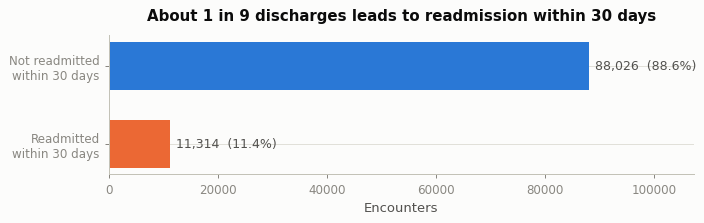

Readmission rate: 11.39%


In [10]:
counts = df['readmit_30'].value_counts()   # class counts (0 = not readmitted, 1 = readmitted)
rate = df['readmit_30'].mean()             # overall 30-day readmission rate

fig, ax = plt.subplots(figsize=(8, 2.6))
labels = ['Not readmitted\nwithin 30 days', 'Readmitted\nwithin 30 days']   # per encounter
vals = [counts[0], counts[1]]
bars = ax.barh(labels[::-1], vals[::-1], color=[ORANGE, BLUE], height=0.62)   # readmitted drawn in orange
for b, v in zip(bars, vals[::-1]):
    ax.text(v + counts[0]*0.012, b.get_y() + b.get_height()/2,               # count + share at each bar end
            f'{v:,}  ({v/len(df):.1%})', va='center', color=INK2, fontsize=10)
ax.set_xlim(0, counts[0]*1.22)                                                # room for the labels
ax.set_title('About 1 in 9 discharges leads to readmission within 30 days')
ax.set_xlabel('Encounters')
style_ax(ax, y_grid_only=True)
plt.tight_layout(); plt.show()

print(f'Readmission rate: {rate:.2%}')

Roughly **11% readmitted vs 89% not** — imbalanced enough that a model predicting "nobody comes back" would score ~89% accuracy while being useless. That single fact drives two decisions later: the metric priority (Section 5.1) and class weighting inside every model (Section 5.3).

### 3.2 Does readmission risk climb with age?

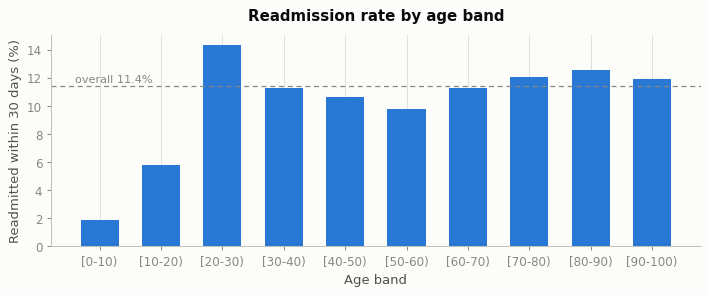

In [11]:
age_rate = df.groupby('age', observed=True)['readmit_30'].agg(['mean', 'count'])   # rate + size per band
age_rate = age_rate[age_rate['count'] > 100]   # tiny bands would just show noise

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.bar(age_rate.index, age_rate['mean'] * 100, color=BLUE, width=0.62)
ax.axhline(rate * 100, color=MUTED, lw=1, ls=(0, (4, 3)))                    # overall rate as a reference line
ax.text(-0.4, rate * 100 + 0.3, f'overall {rate:.1%}', color=MUTED, fontsize=9, ha='left')
ax.set_title('Readmission rate by age band')
ax.set_ylabel('Readmitted within 30 days (%)')
ax.set_xlabel('Age band')
style_ax(ax, y_grid_only=False)
plt.tight_layout(); plt.show()

Not the smooth climb I expected — risk has **two peaks**. It spikes for young adults in their 20s (14.3%, the highest band of all), dips through midlife, then rises again into the 80s. The young-adult spike makes clinical sense for a diabetic population: type-1 patients with unstable disease cycling in and out of hospital. The age bands still have a natural order, so in Section 4 they become a single ordinal feature — the tree models can carve this non-linear shape out of one ordered column.

### 3.3 Prior hospitalizations — the strongest simple signal
`number_inpatient` counts how many times the patient was hospitalized in the year **before** this encounter. My expectation: a patient who keeps ending up in hospital is far more likely to end up there again.

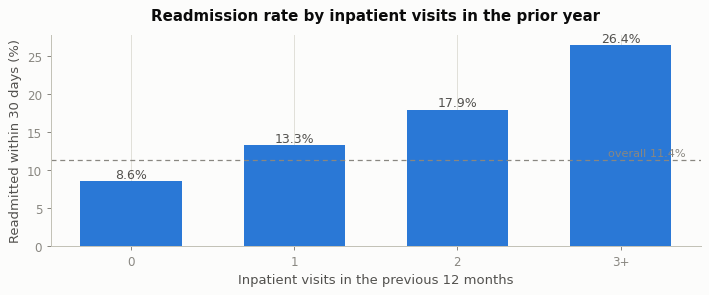

In [12]:
prior = df['number_inpatient'].clip(upper=3)               # 4+ visits are rare; group them as "3+"
labels = ['0', '1', '2', '3+']
prior_rate = df.groupby(prior)['readmit_30'].agg(['mean', 'count'])   # rate + group size per visit count

fig, ax = plt.subplots(figsize=(8, 3.4))
bars = ax.bar(labels, prior_rate['mean'] * 100, color=BLUE, width=0.62)
for b, (m, n) in zip(bars, prior_rate.values):
    ax.text(b.get_x() + b.get_width()/2, m*100 + 0.4, f'{m:.1%}',   # rate labeled above each bar
            ha='center', color=INK2, fontsize=10)
ax.axhline(rate * 100, color=MUTED, lw=1, ls=(0, (4, 3)))            # overall rate as a reference line
ax.text(3.4, rate * 100 + 0.4, f'overall {rate:.1%}', color=MUTED, fontsize=9, ha='right')
ax.set_title('Readmission rate by inpatient visits in the prior year')
ax.set_ylabel('Readmitted within 30 days (%)')
ax.set_xlabel('Inpatient visits in the previous 12 months')
style_ax(ax, y_grid_only=False)
plt.tight_layout(); plt.show()

Exactly as expected, and steeply so: encounters with 3+ prior hospitalizations end in readmission **26.4%** of the time — more than double the overall rate, and three times the rate of patients with no prior stays (8.6%). This should be a top feature in any model that's paying attention — a check I come back to in Section 6.

### 3.4 Where the patient went after discharge
Discharge disposition is recorded **at discharge** — before any readmission happens — so it's fair game as a predictor. Grouping the 20+ raw codes into five destinations (the full grouping happens in Section 4):

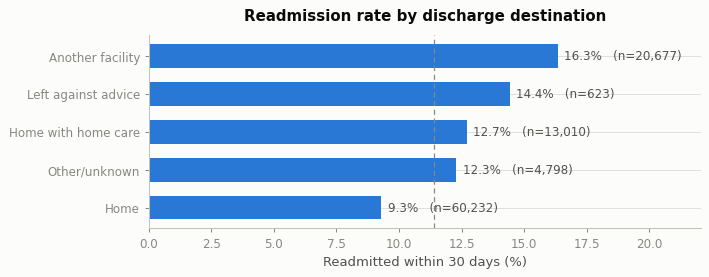

In [13]:
def discharge_group(code):
    # collapse 20+ raw disposition codes into 5 groups that mean something
    if code == 1:                                          return 'Home'
    if code in (6, 8):                                     return 'Home with home care'
    if code in (2, 3, 4, 5, 22, 23, 24, 27, 28, 29, 30):   return 'Another facility'
    if code == 7:                                          return 'Left against advice'
    return 'Other/unknown'

disch = df['discharge_disposition_id'].map(discharge_group)
disch_rate = (df.groupby(disch)['readmit_30'].agg(['mean', 'count'])   # readmission rate per destination
                .sort_values('mean'))

fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.barh(disch_rate.index, disch_rate['mean'] * 100, color=BLUE, height=0.62)
for b, (m, n) in zip(bars, disch_rate.values):
    ax.text(m*100 + 0.25, b.get_y() + b.get_height()/2,                # rate + group size at each bar end
            f'{m:.1%}   (n={n:,.0f})', va='center', color=INK2, fontsize=9.5)
ax.axvline(rate * 100, color=MUTED, lw=1, ls=(0, (4, 3)))              # overall rate as a reference line
ax.set_xlim(0, disch_rate['mean'].max() * 100 * 1.35)
ax.set_title('Readmission rate by discharge destination')
ax.set_xlabel('Readmitted within 30 days (%)')
style_ax(ax, y_grid_only=True)
plt.tight_layout(); plt.show()

A clean risk gradient: patients discharged **home** come back least (9.3%), patients sent to **another facility** the most (16.3%), with home-care and other destinations in between. Two readings worth separating: the facility effect isn't the discharge *causing* readmission — sicker patients get sent to facilities — but it's information available on discharge day, which makes it fair game for prediction. And the **left-against-advice** group (14.5%) is a different story: not sicker on paper, just untreated. Either way, discharge destination looks like it should carry real signal.

### 3.5 Do the numeric features overlap?
Before modeling, a check on whether any of the count-style features are near-duplicates of each other.

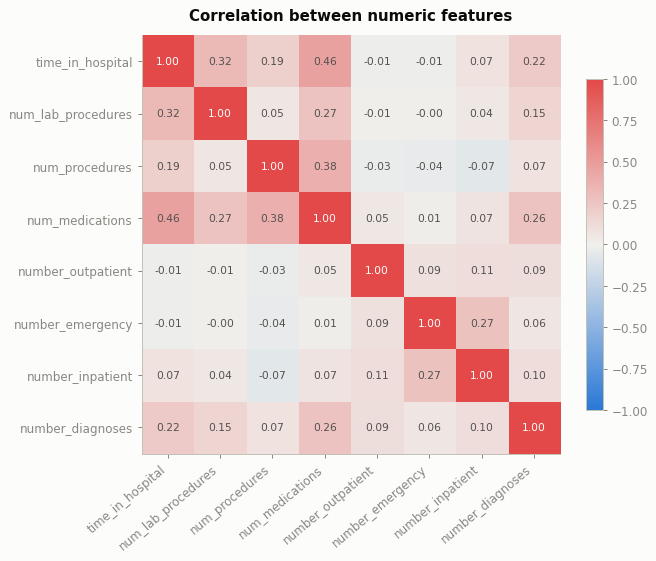

In [14]:
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
            'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

corr = df[num_cols].corr()                             # pairwise correlations
fig, ax = plt.subplots(figsize=(7.6, 6.4))
im = ax.imshow(corr, cmap=DIVERGING, vmin=-1, vmax=1)  # blue = negative, red = positive
ax.set_xticks(range(len(num_cols)), num_cols, rotation=40, ha='right')
ax.set_yticks(range(len(num_cols)), num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        v = corr.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8.5,
                color='#ffffff' if abs(v) > 0.55 else INK2)   # white text only on dark cells
ax.grid(visible=False)
ax.set_title('Correlation between numeric features')
fig.colorbar(im, ax=ax, shrink=0.75)
plt.tight_layout(); plt.show()

No problematic overlap. The strongest pair is `time_in_hospital` × `num_medications` (~0.46) — longer stays mean more treatment, which is expected and mild. All eight numeric features stay.

<a id="s4"></a>
# 4. Feature preparation
The raw file mixes clean numeric counts with coded ID fields, 10-year age bands, three ICD-9 diagnosis codes, and 23 per-drug columns. Each group gets its own treatment, with one goal throughout: **keep the feature set small and readable** rather than exploding hundreds of sparse columns.

### 4.1 Grouping the coded ID fields
`admission_type_id`, `discharge_disposition_id` and `admission_source_id` are integers that stand for categories (the mappings ship with the dataset). Treating them as numbers would invent a fake ordering, and one-hot encoding all the raw codes would create dozens of near-empty columns. Instead, each gets collapsed into a handful of groups that mean something:

In [15]:
# admission type: 8 codes -> 5 groups (codes 5, 6, 8 are all flavors of "unknown")
adm_type_map = {1: 'Emergency', 2: 'Urgent', 3: 'Elective', 4: 'Newborn',
                5: 'Unknown', 6: 'Unknown', 7: 'Trauma', 8: 'Unknown'}
df['admission_type'] = df['admission_type_id'].map(adm_type_map)

# discharge destination: same grouping used in the EDA above
df['discharge_to'] = df['discharge_disposition_id'].map(discharge_group)

# admission source: physician/clinic referral vs the ER vs a transfer in
def source_group(code):
    if code in (1, 2, 3):                       return 'Referral'
    if code == 7:                               return 'Emergency room'
    if code in (4, 5, 6, 10, 18, 22, 25, 26):   return 'Transfer in'
    return 'Other/unknown'
df['admission_source'] = df['admission_source_id'].map(source_group)

df[['admission_type', 'discharge_to', 'admission_source']].apply(lambda s: s.value_counts())

,admission_type,discharge_to,admission_source
Another facility,NaN,20677.0,NaN
Elective,18667.0,NaN,NaN
Emergency,52369.0,NaN,NaN
Emergency room,NaN,NaN,55848.0
Home,NaN,60232.0,NaN
Home with home care,NaN,13010.0,NaN
Left against advice,NaN,623.0,NaN
Newborn,10.0,NaN,NaN
Other/unknown,NaN,4798.0,6874.0
Referral,NaN,NaN,30433.0


### 4.2 Primary diagnosis → ICD-9 chapters
`diag_1` holds the primary diagnosis as one of 700+ ICD-9 codes — far too many to encode directly. But ICD-9 codes have structure: numeric ranges correspond to body systems. Mapping each code to its chapter turns 700+ values into nine readable groups (circulatory, respiratory, diabetes itself, and so on). The secondary diagnoses (`diag_2`, `diag_3`) get dropped — the primary diagnosis carries the headline signal, and one grouped diagnosis keeps the model interpretable.

In [16]:
def icd9_chapter(code):
    # map a raw ICD-9 code to its chapter (body system) using the standard numeric ranges
    if pd.isna(code):
        return 'Missing'
    s = str(code)
    if s.startswith(('V', 'E')):        # supplementary / external-cause codes
        return 'Other'
    v = float(s)
    if 250 <= v < 251:      return 'Diabetes'         # all 250.xx codes
    if 390 <= v <= 459 or v == 785:  return 'Circulatory'
    if 460 <= v <= 519 or v == 786:  return 'Respiratory'
    if 520 <= v <= 579 or v == 787:  return 'Digestive'
    if 580 <= v <= 629 or v == 788:  return 'Genitourinary'
    if 800 <= v <= 999:     return 'Injury'
    if 710 <= v <= 739:     return 'Musculoskeletal'
    if 140 <= v <= 239:     return 'Neoplasms'
    return 'Other'

df['primary_diag'] = df['diag_1'].map(icd9_chapter)
df['primary_diag'].value_counts()

primary_diag
Circulatory        29680
Other              17793
Respiratory        13934
Digestive           9333
Diabetes            8661
Injury              6851
Genitourinary       5002
Musculoskeletal     4935
Neoplasms           3131
Missing               20
Name: count, dtype: int64

### 4.3 Age bands → one ordinal feature
The ten age bands are ordered, and Section 3.2 showed risk moving with age. One integer (0 for `[0-10)` up to 9 for `[90-100)`) preserves that ordering — ten one-hot columns would throw it away.

In [17]:
age_map = {f'[{10*i}-{10*(i+1)})': i for i in range(10)}   # '[0-10)' -> 0 ... '[90-100)' -> 9
df['age_num'] = df['age'].map(age_map)

### 4.4 Medications → three flags and a count
The 23 per-drug columns record dosage status (`No` / `Steady` / `Up` / `Down`) for each diabetes medication. Per-drug dosage detail is more granularity than ~70K rows can support, so I compress them into what plausibly matters at discharge:

- **how many** diabetes medications the patient is on,
- whether they're on **insulin** specifically (the heavy hitter),
- whether **any medication was changed** during the stay (a changed regimen suggests the previous one wasn't working),
- whether they're on **any** diabetes medication at all.

In [18]:
drug_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
             'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
             'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide',
             'citoglipton', 'insulin', 'glyburide.metformin', 'glipizide.metformin',
             'glimepiride.pioglitazone', 'metformin.rosiglitazone', 'metformin.pioglitazone']

on_drug = df[drug_cols].ne('No')                        # any status except "No" means "on this drug"
df['n_diabetes_meds'] = on_drug.sum(axis=1)             # how many diabetes drugs at once
df['insulin_on'] = on_drug['insulin'].astype(int)       # on insulin specifically
df['med_change'] = (df['change'] == 'Ch').astype(int)   # any medication changed during the stay
df['on_diabetes_med'] = (df['diabetesMed'] == 'Yes').astype(int)   # on any diabetes medication

df[['n_diabetes_meds', 'insulin_on', 'med_change', 'on_diabetes_med']].mean().round(3)

n_diabetes_meds    1.187
insulin_on         0.533
med_change         0.464
on_diabetes_med    0.772
dtype: float64

### 4.5 Patient history — what earlier stays say about the next one
The grouped split (Section 5.2) lets me keep every encounter — which means each encounter can also *know about the patient's earlier stays in the data*. Everything below is built strictly from the **past**: the encounter list is sorted in encounter order, and each row only sees stays that came before it. (The dataset has no admission dates, so encounter order stands in for time — a documented assumption, flagged in the limitations.)

In [19]:
df = df.sort_values('encounter_id')                 # encounter order = the dataset's stand-in for time
by_patient = df.groupby('patient_nbr')

df['prior_stays_in_data'] = by_patient.cumcount()   # how many earlier stays this patient has in the data
df['prev_readmit30'] = (by_patient['readmit_30'].shift(1)   # did the PREVIOUS stay end in a 30-day readmission?
                        .fillna(0).astype(int))             # first stay has no previous -> 0
df['prev_time_in_hospital'] = (by_patient['time_in_hospital'].shift(1)   # length of the previous stay
                               .fillna(0))
df['cum_time_in_hospital'] = (by_patient['time_in_hospital'].cumsum()    # total days in hospital BEFORE
                              - df['time_in_hospital'])                  # this stay (exclude the current one)

df[['prior_stays_in_data', 'prev_readmit30', 'prev_time_in_hospital', 'cum_time_in_hospital']].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
prior_stays_in_data,99340.0,0.63,1.53,0.0,0.0,0.0,1.0,39.0
prev_readmit30,99340.0,0.08,0.27,0.0,0.0,0.0,0.0,1.0
prev_time_in_hospital,99340.0,1.35,2.64,0.0,0.0,0.0,2.0,14.0
cum_time_in_hospital,99340.0,2.87,7.58,0.0,0.0,0.0,2.0,169.0


### 4.6 What I dropped, and why
- **Identifiers** (`id`, `encounter_id`, `patient_nbr`) — carry no signal by construction.
- **`weight`** — ~97% missing; effectively not collected.
- **`payer_code`** — who pays shouldn't drive a clinical risk model, and it's 40% missing anyway.
- **`medical_specialty`** — half missing with 80+ sparse values; grouping the other half wasn't worth a feature the model can barely use.
- **`diag_2`, `diag_3`** — secondary diagnoses, dropped in favor of the grouped primary diagnosis (Section 4.2).

### 4.7 The final feature set and the pipeline
Everything downstream — scaling, encoding, every model — runs inside a single pipeline. This matters for one specific reason: **the scaler is fit on training data only, inside each cross-validation fold**. Statistics from the test set never touch anything the model learns from.

In [20]:
num_feats = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
             'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses',
             'age_num', 'n_diabetes_meds',
             'prior_stays_in_data', 'prev_time_in_hospital', 'cum_time_in_hospital']   # patient history (4.5)
bin_feats = ['med_change', 'on_diabetes_med', 'insulin_on',
             'prev_readmit30']                                         # already 0/1 -- pass through untouched
cat_feats = ['race', 'gender', 'admission_type', 'discharge_to', 'admission_source',
             'primary_diag', 'max_glu_serum', 'A1Cresult']

X = df[num_feats + bin_feats + cat_feats]   # the 21 features
y = df['readmit_30']                        # the target
patient = df['patient_nbr']                 # NOT a feature -- used in 5.2 to split by patient

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_feats),   # numeric features to one ruler -- fit on train folds only
    ('bin', 'passthrough', bin_feats),      # binary flags need no scaling
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), cat_feats),   # categories -> dummies
])

print(f'{X.shape[0]:,} encounters from {patient.nunique():,} patients, '
      f'{X.shape[1]} features before encoding')

99,340 encounters from 69,987 patients, 25 features before encoding


<a id="s5"></a>
# 5. Modeling
### 5.1 Metric priority, stated up front
With a 91/9 class split, raw accuracy is the wrong yardstick — "nobody gets readmitted" scores 91%. The priority for this project:

1. **ROC-AUC** (primary) — how well the model *ranks* risky patients above safe ones, independent of any threshold.
2. **Recall on the readmitted class** at a chosen operating point (secondary) — a readmission risk model earns its keep as a screening tool, and a screening tool that misses most readmissions is pointless.
3. **Accuracy** — reported for context, never optimized.

Class imbalance is handled by **balanced class weights** rather than by throwing away majority-class rows: every patient stays in the training data, and the test set keeps its real-world class mix. (Gradient boosting takes the same balancing as per-row sample weights, since it has no class-weight setting of its own.)

### 5.2 Split — by patient, not by row
This is where the Section 2.2 leakage trap gets closed. A grouped 80/20 split works like an ordinary train/test split with one change: instead of dealing out rows, it deals out **patients** — every encounter belonging to a patient lands on the same side. The model can never be graded on a person it trained on, and no data had to be thrown away to get that guarantee. (A grouped split can't stratify at the same time, but with ~100K rows both halves land within a whisker of the same readmission rate — verified below.)

In [21]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)   # like train_test_split,
train_idx, test_idx = next(splitter.split(X, y, groups=patient))             # but it deals out patients

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
patient_train = patient.iloc[train_idx]        # kept for the grouped CV folds in 5.3/5.4

# prove the guarantee: not a single patient appears on both sides
overlap = set(patient_train) & set(patient.iloc[test_idx])
print(f'patients in both train and test: {len(overlap)}')

# balanced per-row weights for gradient boosting: readmitted rows count ~8x, so the
# rare class carries the same total weight as the majority (same idea as class_weight='balanced')
sample_weights = compute_sample_weight('balanced', y_train)

print(f'train {X_train.shape[0]:,} ({y_train.mean():.2%} readmitted)   '
      f'test {X_test.shape[0]:,} ({y_test.mean():.2%} readmitted)')

patients in both train and test: 0
train 79,567 (11.40% readmitted)   test 19,773 (11.35% readmitted)


### 5.3 Baseline comparison
Four candidates, each cross-validated on the training set with AUC as the yardstick. The CV folds are **grouped by patient too** — same leakage rule inside the folds as at the outer split. The dummy model anchors the bottom of the scale; the logistic regression is the interpretable baseline the stronger models have to beat.

In [22]:
candidates = {
    'Always predict the base rate': DummyClassifier(strategy='prior'),                     # the no-skill floor
    'Logistic regression': LogisticRegression(max_iter=2000, class_weight='balanced'),     # interpretable baseline
    'Random forest': RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                            random_state=SEED, n_jobs=-1),                 # bagged trees
    'Gradient boosting': GradientBoostingClassifier(random_state=SEED),                    # boosted trees (weighted below)
}

rows = []
for name, model in candidates.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)])          # preprocessing + model as one unit
    fit_params = {}                                                    # extra arguments passed to .fit()
    if name == 'Gradient boosting':
        fit_params = {'model__sample_weight': sample_weights}          # its class balancing (see 5.1)
    aucs = cross_val_score(pipe, X_train, y_train, scoring='roc_auc',  # 5 patient-grouped folds, judged by AUC
                           cv=GroupKFold(n_splits=5), groups=patient_train,
                           n_jobs=-1, params=fit_params)
    rows.append([name, aucs.mean(), aucs.std()])

baseline_results = pd.DataFrame(rows, columns=['Model', 'CV AUC (mean)', 'CV AUC (std)'])
baseline_results.round(4)

/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,Model,CV AUC (mean),CV AUC (std)
0,Always predict the base rate,0.5000,0.0000
1,Logistic regression,0.6579,0.0049
2,Random forest,0.6417,0.0063
3,Gradient boosting,0.6647,0.0041


Gradient boosting leads, with the logistic regression close behind — and notably, the plain logistic model beats the random forest. When a linear model runs this close to the tree ensembles, the signal in the data is mostly additive and there isn't much interaction structure left to mine. That caps how much tuning can add, which the next step confirms.

### 5.4 Tuning the leader
A small grid over the two knobs that matter most for boosted trees — the learning rate and how deep each tree can go — tuned on cross-validated AUC. A wide grid isn't warranted when the baseline spread across model families is this tight.

In [23]:
gb_pipe = Pipeline([('prep', preprocess),
                    ('model', GradientBoostingClassifier(random_state=SEED))])

search = GridSearchCV(gb_pipe,                                     # the pipeline to tune
    param_grid = {'model__learning_rate': [0.05, 0.1],             # how big each boosting step is
                  'model__max_depth': [2, 3, 4]},                  # how deep each tree can go
    cv=GroupKFold(n_splits=5), scoring='roc_auc', n_jobs=-1)       # patient-grouped folds, judged by AUC
search.fit(X_train, y_train, groups=patient_train,                 # runs every candidate, training data only
           model__sample_weight=sample_weights)

print('best params:', search.best_params_)         # the winning combination
print(f'best CV AUC: {search.best_score_:.4f}')    # its averaged cross-validated AUC
gb_model = search.best_estimator_                  # the tuned model, refit on all of X_train

best params: {'model__learning_rate': 0.1, 'model__max_depth': 3}
best CV AUC: 0.6647


### 5.5 Test-set evaluation
The moment of truth: both the tuned model and the logistic baseline, evaluated once on the 20% of patients neither has ever seen.

In [24]:
lr_model = Pipeline([('prep', preprocess),
                     ('model', LogisticRegression(max_iter=2000, class_weight='balanced'))])
lr_model.fit(X_train, y_train)                       # the interpretable baseline, fit on the training set

gb_probs = gb_model.predict_proba(X_test)[:, 1]      # predicted readmission probability per test patient
lr_probs = lr_model.predict_proba(X_test)[:, 1]

gb_auc, lr_auc = roc_auc_score(y_test, gb_probs), roc_auc_score(y_test, lr_probs)
gb_ap = average_precision_score(y_test, gb_probs)    # PR-AUC -- how precision holds up as recall grows

print(f'Gradient boosting   test AUC {gb_auc:.4f}   PR-AUC {gb_ap:.4f} '
      f'(base rate {y_test.mean():.4f})')
print(f'Logistic regression test AUC {lr_auc:.4f}')

Gradient boosting   test AUC 0.6718   PR-AUC 0.2148 (base rate 0.1135)
Logistic regression test AUC 0.6647


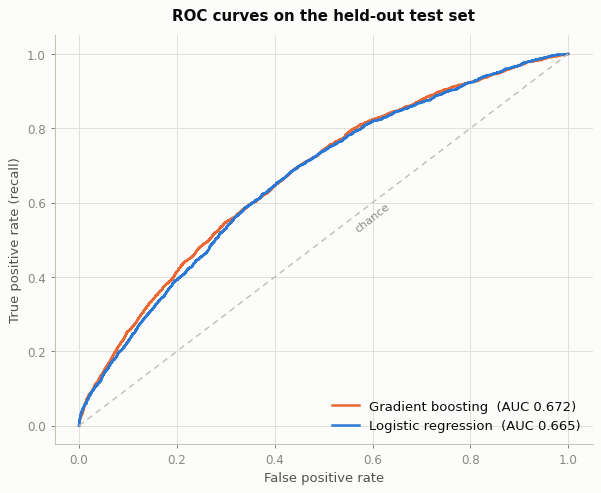

In [25]:
fig, ax = plt.subplots(figsize=(6.8, 5.6))
for probs, name, color in [(gb_probs, 'Gradient boosting', ORANGE),
                           (lr_probs, 'Logistic regression', BLUE)]:
    fpr, tpr, _ = roc_curve(y_test, probs)                       # the full threshold sweep
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC {auc:.3f})')
ax.plot([0, 1], [0, 1], color=BASELINE, lw=1.2, ls=(0, (4, 3)))  # the no-skill diagonal
ax.text(0.56, 0.52, 'chance', color=MUTED, fontsize=9, rotation=38)
ax.set_title('ROC curves on the held-out test set')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate (recall)')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

Two readings of this chart:

- **Readmission is hard to predict.** An AUC around 0.67 is the honest ceiling for this feature set, and published work on this dataset lands in the same band. Anything much higher on these features should raise suspicion of leakage, not applause.
- **The two curves nearly touch.** The tuned boosted model buys only a small edge over plain logistic regression — consistent with the mostly-additive signal seen in the baseline table.

### 5.6 An operating point for screening
AUC measures ranking; using the model requires choosing a threshold. For a screening tool, missing a readmission costs more than a false alarm, so I pick the threshold where the model catches **~60% of readmissions** and accept the false alarms that come with it.

In [26]:
prec_curve, rec_curve, thresholds = precision_recall_curve(y_test, gb_probs)   # every possible threshold
idx = np.argmin(np.abs(rec_curve[:-1] - 0.60))    # the threshold closest to 60% recall
threshold = thresholds[idx]

y_flag = (gb_probs >= threshold).astype(int)      # 1 = flagged for follow-up
flagged = y_flag.mean()                           # share of discharges flagged
print(f'threshold {threshold:.3f} -> flags {flagged:.1%} of discharges, '
      f'recall {rec_curve[idx]:.1%}, precision {prec_curve[idx]:.1%}')
print()
print(classification_report(y_test, y_flag, target_names=['not readmitted', 'readmitted'], digits=3))

threshold 0.509 -> flags 38.4% of discharges, recall 60.0%, precision 17.7%

                precision    recall  f1-score   support

not readmitted      0.926     0.644     0.760     17529
    readmitted      0.177     0.600     0.274      2244

      accuracy                          0.639     19773
     macro avg      0.552     0.622     0.517     19773
  weighted avg      0.841     0.639     0.704     19773



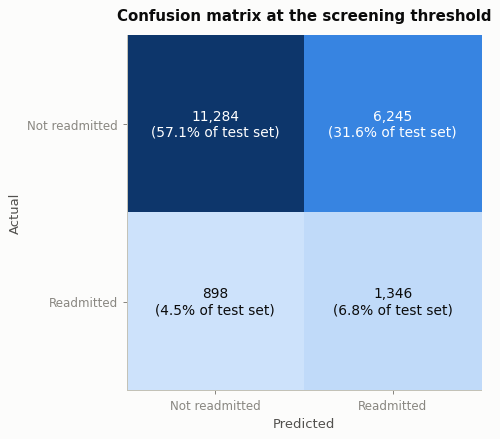

In [27]:
cm = confusion_matrix(y_test, y_flag)             # counts of right/wrong calls at this threshold
fig, ax = plt.subplots(figsize=(6.2, 5))
im = ax.imshow(cm, cmap=BLUES)
ticklabels = ['Not readmitted', 'Readmitted']
ax.set_xticks([0, 1], ticklabels); ax.set_yticks([0, 1], ticklabels)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
for i in range(2):
    for j in range(2):
        share = cm[i, j] / cm.sum()
        ax.text(j, i, f'{cm[i, j]:,}\n({share:.1%} of test set)', ha='center', va='center',
                fontsize=11, color='#ffffff' if cm[i, j] > cm.max()*0.5 else INK)
ax.grid(visible=False)
ax.set_title('Confusion matrix at the screening threshold')
plt.tight_layout(); plt.show()

The trade in plain terms: to catch **3 in 5** of the readmissions, the model flags **about 38% of all discharges** for follow-up, and most of those flags are false alarms (precision ~18%). Whether that trade is worth it depends on what the follow-up costs — a phone call within a week is cheap enough that casting a wide net can still make sense; sending a nurse to every flagged home would not be. The model ranks; the economics pick the threshold.

<a id="s6"></a>
# 6. What drives readmission risk
Two models, two completely different ways of asking "what mattered?" — odds ratios from the logistic regression, feature importances from the gradient-boosting model. If both point at the same features, the signal is real and not an artifact of either model's assumptions.

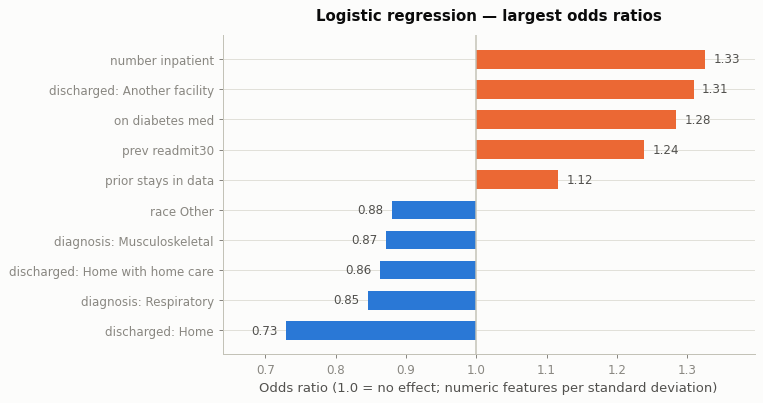

In [28]:
feat_names = lr_model.named_steps['prep'].get_feature_names_out()          # names after encoding
odds = pd.Series(np.exp(lr_model.named_steps['model'].coef_[0]), index=feat_names)   # coefficient -> odds ratio
odds = odds[[f for f in odds.index if not f.endswith(('_None', '_Norm'))]]  # keep the readable ones
top_odds = pd.concat([odds.nsmallest(5), odds.nlargest(5)]).sort_values()   # 5 most protective + 5 riskiest

clean = (top_odds.rename(lambda s: s.split('__', 1)[1]                      # tidy the names for the chart
                         .replace('_', ' ').replace('discharge to', 'discharged:')
                         .replace('admission source', 'admitted via:')
                         .replace('primary diag', 'diagnosis:')))

fig, ax = plt.subplots(figsize=(8.6, 4.6))
colors = [BLUE if v < 1 else ORANGE for v in clean.values]                  # blue = protective, orange = risk
ax.barh(clean.index, clean.values - 1, left=1, color=colors, height=0.62)   # bars grow away from 1.0
ax.axvline(1, color=BASELINE, lw=1.2)                                       # 1.0 = no effect
ax.set_xlim(clean.min() - 0.09, clean.max() + 0.07)                         # room for the value labels
for i, v in enumerate(clean.values):
    ax.text(v + (0.012 if v >= 1 else -0.012), i, f'{v:.2f}',
            va='center', ha='left' if v >= 1 else 'right', color=INK2, fontsize=9.5)
ax.set_title('Logistic regression — largest odds ratios')
ax.set_xlabel('Odds ratio (1.0 = no effect; numeric features per standard deviation)')
style_ax(ax, y_grid_only=True)
plt.tight_layout(); plt.show()

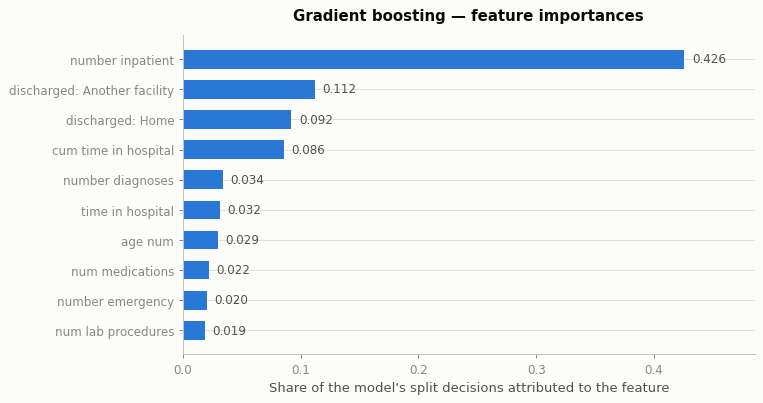

In [29]:
importances = pd.Series(gb_model.named_steps['model'].feature_importances_,   # how much each feature
                        index=feat_names)                                     # contributed to the trees' splits
top_imp = importances.nlargest(10).sort_values()

clean_imp = (top_imp.rename(lambda s: s.split('__', 1)[1]                     # same tidy names as above
                            .replace('_', ' ').replace('discharge to', 'discharged:')
                            .replace('admission source', 'admitted via:')
                            .replace('primary diag', 'diagnosis:')))

fig, ax = plt.subplots(figsize=(8.6, 4.6))
ax.barh(clean_imp.index, clean_imp.values, color=BLUE, height=0.62)
for i, v in enumerate(clean_imp.values):
    ax.text(v + top_imp.max()*0.015, i, f'{v:.3f}', va='center', color=INK2, fontsize=9.5)
ax.set_xlim(0, top_imp.max()*1.14)
ax.set_title('Gradient boosting — feature importances')
ax.set_xlabel('Share of the model\'s split decisions attributed to the feature')
style_ax(ax, y_grid_only=True)
plt.tight_layout(); plt.show()

**The two models agree.** Both put the same features at the top:

- **Prior hospitalization, in every form** — the dominant signal in both models. `number_inpatient` alone has the largest odds ratio (1.33 per standard deviation) and 43% of the boosted model's split decisions, and the Section 4.5 history features reinforce it from three angles: a previous stay that ended in readmission raises the odds 1.24×, each additional prior stay on record 1.12×, and cumulative prior days in hospital is the #4 tree feature. Past hospitalization is the classic predictor of future hospitalization, and this data says so emphatically.
- **Discharge destination** — the clear second in both. Being discharged home is protective (odds ratio 0.73); being sent to another facility raises the odds (1.31). As Section 3.4 noted, this mostly encodes how sick the patient was — but it's known at discharge time, which is what a discharge-day risk model is allowed to use.
- **Age and primary diagnosis** — smaller but consistent. Age contributes modestly in the trees (which can carve its two-peak shape from Section 3.2); the diagnosis chapters carry direction in the linear model (respiratory and musculoskeletal protective, ~0.85–0.87) while ranking low in the trees. Direction from the odds ratios, ranking from the importances.

One caveat on reading the importance chart: split-based importances can flatter numeric features (they offer more places to split), so I treat the chart as a ranking, not as exact effect sizes — the odds ratios next to it are what carry the direction and magnitude. Nothing exotic drove the model either way: no lab value outranked the simple story of *how sick, how often hospitalized, how old, and where they went next*.

<a id="s7"></a>
# 7. Conclusion & limitations

**What was found.** From ~99,000 encounters of ~70,000 diabetic patients — split by patient so no one is both trained and tested on — a tuned gradient-boosting model predicts 30-day readmission with a test AUC of ~0.67: meaningfully better than chance, close to the practical ceiling for this feature set, and only a small step ahead of a plain logistic regression. Two unrelated models agree on the drivers: discharge destination, prior hospitalizations, age, and primary diagnosis. As a screening tool with a recall-oriented threshold, the model catches about 3 in 5 readmissions.

**What helped, and what didn't.** The single biggest gain in this project came from a *design* decision, not an algorithm: keeping all encounters and closing the leakage trap with a patient-grouped split, instead of discarding every repeat visit (an earlier first-encounter version of this analysis topped out at AUC 0.645; the grouped design added more than +0.02, and the patient-history features of Section 4.5 a further +0.004). By contrast, the obvious "more" moves — a much wider hyperparameter search, extra features (grouped secondary diagnoses, admitting specialty, dosage-change counts), blending the two models' rankings — bought about **0.002 AUC** between them. On this dataset, the ceiling belongs to the data design and the features, not to the algorithm or its settings.

**Limitations, honestly stated:**

- **The data is old (1999–2008) and American.** Diabetes care has changed since; nothing here transfers to another health system without revalidation.
- **AUC 0.67 is modest.** It supports prioritizing follow-up calls, not clinical decisions about individuals.
- **Repeat encounters aren't independent.** The grouped split keeps evaluation honest, but frequent flyers contribute more rows than one-time patients, so the model leans toward the repeat-visit population — which is also the population a screening tool most needs to serve.
- **Precision at the screening threshold is modest** — most flags are false alarms, tolerable only when follow-up is cheap.
- **Encounter order stands in for time.** The dataset has no admission dates, so the patient-history features assume encounter IDs are chronological — standard practice with this dataset, but an assumption all the same.
- **No external validation.** One dataset, one split; the honest next step would be validating on a different hospital system's data.

**If I extended this:** the diagnosis chapters could be replaced with clinically-defined comorbidity groupings, the threshold analysis could become a proper cost curve once real follow-up costs are attached, and the single train/test split could become a repeated or nested cross-validation to put an error bar on the headline AUC.

<a id="appendix"></a>
# Appendix — Feature reference
Descriptions follow the dataset's official documentation.

| Feature | What it is |
|---|---|
| `race`, `gender`, `age` | Demographics; age comes in 10-year bands |
| `admission_type_id` | How the admission happened (emergency, urgent, elective, ...) |
| `discharge_disposition_id` | Where the patient went at discharge (home, facility, hospice, ...) |
| `admission_source_id` | How the patient arrived (referral, ER, transfer, ...) |
| `time_in_hospital` | Length of stay, days |
| `num_lab_procedures`, `num_procedures`, `num_medications` | Counts during the encounter |
| `number_outpatient`, `number_emergency`, `number_inpatient` | Visits in the 12 months before the encounter |
| `diag_1`, `diag_2`, `diag_3` | ICD-9 diagnosis codes (primary + secondary) |
| `number_diagnoses` | Total diagnoses recorded |
| `max_glu_serum`, `A1Cresult` | Lab results, or "not measured" |
| 23 medication columns | Per-drug status: no / steady / up / down |
| `change`, `diabetesMed` | Any medication change; any diabetes medication |
| `readmitted` | `<30`, `>30`, or `NO` — collapsed to a binary 30-day target here |